In [67]:
import torch
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"Device Name: {torch.cuda.get_device_name(0)}")

CUDA Available: True
Device Name: NVIDIA GeForce RTX 3060


In [68]:
import pandas as pd
import re
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

In [69]:
# Load dataset mentah
df = pd.read_csv('data/raw/Wondr_BNI_reviews.csv') # Ganti sesuai bank yang mau diolah

# 1. Filter Rating 1, 2, 3 saja (Kategori Keluhan)
df = df[df['score'] <= 3]

print(f"Total data keluhan awal: {len(df)} ulasan.")
df.head()

Total data keluhan awal: 21252 ulasan.


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
3,6d483361-3627-4f5d-86f2-504b96b63f40,Haris Haryadi,https://play-lh.googleusercontent.com/a/ACg8oc...,"kenapa sekarang sering eror pdhl lg butuh bgt,...",2,0,1.4.4,2025-12-31 22:10:17,"Halo Kak Haris Haryadi, maaf atas kendalanya y...",2026-01-01 08:39:38,1.4.4
10,d37cc5a3-86de-476e-918c-ff2062ad2544,Syamsuddin Nor,https://play-lh.googleusercontent.com/a-/ALV-U...,"Pengaktifan biometriknya bermasalah, tombol sa...",3,0,NaN,2025-12-31 20:37:38,"Hai Kak Syamsuddin Nor, maaf untuk kendalanya....",2025-12-31 21:57:46,NaN
25,38aeafae-1145-4a00-8a71-2ddc11e5a884,Linawijin Al,https://play-lh.googleusercontent.com/a-/ALV-U...,aplikasi jelek baget udah masukin no debit mas...,1,0,NaN,2025-12-31 18:54:49,"Hai Kak Linawijin Al, maaf buat kendalanya ya ...",2025-12-31 21:45:20,NaN
26,842b0e64-b01a-4e3b-b086-06ce15a0b5d9,Sandika Priatmoko,https://play-lh.googleusercontent.com/a-/ALV-U...,"eror dihape saya, force close mulu.",1,0,1.4.4,2025-12-31 18:54:06,"Hai Kak Sandika Priatmoko, maaf buat kendalany...",2025-12-31 21:19:55,1.4.4
30,437f5b54-70fe-4004-905d-c45b4bca269f,Angga Enggar Pribadi,https://play-lh.googleusercontent.com/a/ACg8oc...,gimana ini Min saya melakukan transaksi berupa...,1,0,1.4.4,2025-12-31 18:36:18,"Hai Kak Angga Enggar Pribadi, maaf buat kendal...",2025-12-31 21:16:34,1.4.4


# EDA

In [70]:
df.isnull().sum()

reviewId                   0
userName                   0
userImage                  0
content                    0
score                      0
thumbsUpCount              0
reviewCreatedVersion    3594
at                         0
replyContent             109
repliedAt                109
appVersion              3594
dtype: int64

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\PC\AppData\Local\Temp\ipykernel_13204\3338298009.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='score', palette='viridis')


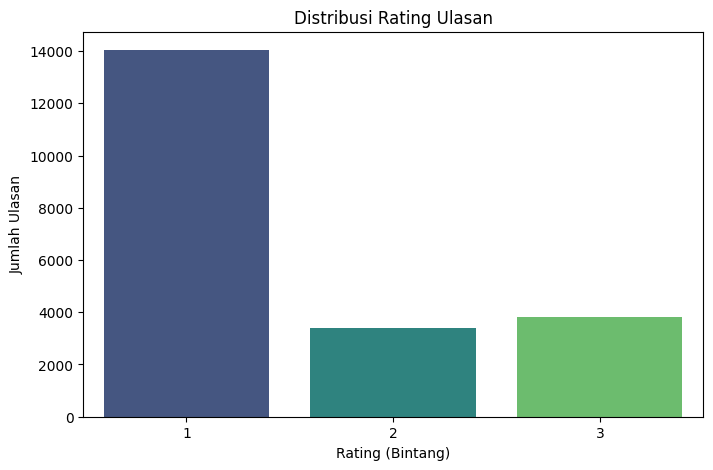

In [72]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='score', palette='viridis')
plt.title('Distribusi Rating Ulasan')
plt.xlabel('Rating (Bintang)')
plt.ylabel('Jumlah Ulasan')
plt.show()

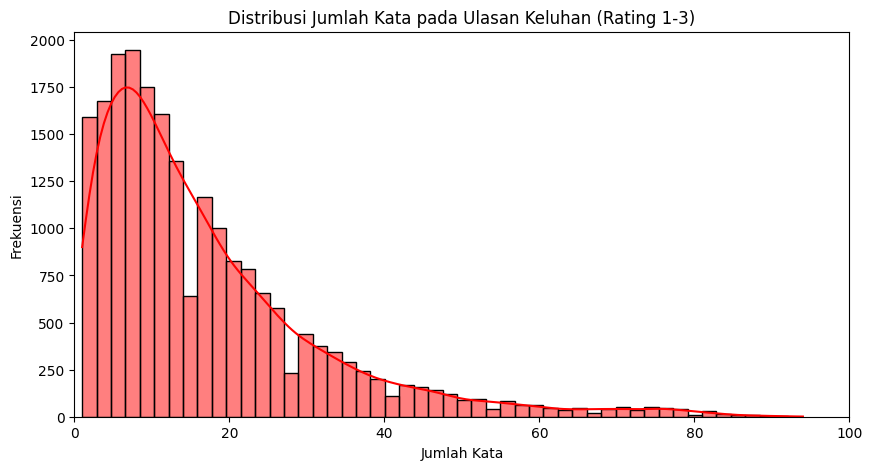

In [73]:
df['char_length'] = df['content'].astype(str).apply(len)
df['word_count'] = df['content'].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
sns.histplot(df[df['score'] <= 3]['word_count'], bins=50, kde=True, color='red')
plt.title('Distribusi Jumlah Kata pada Ulasan Keluhan (Rating 1-3)')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.xlim(0, 100) # Batasi x-axis biar visualnya fokus
plt.show()

# Cleaning

In [74]:
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

In [75]:
df = df[['content', 'score', 'at', 'word_count']]
print(f"\nTotal data keluhan siap dibersihkan: {len(df)} baris")


Total data keluhan siap dibersihkan: 21252 baris


In [76]:
def clean_text_basic(text):
  text = str(text).lower()
  text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
  text = re.sub(r'[^a-z\s]', ' ', text)
  text = stopword_remover.remove(text)
  text = re.sub(r'\s+', ' ', text).strip()
  return text

df['content_cleaned'] = df['content'].apply(clean_text_basic)

In [77]:
# post cleaning checking
df['cleaned_word_count'] = df['content_cleaned'].apply(lambda x: len(str(x).split()))

# Buang ulasan yang sekarang jadi kurang dari 3 kata
df_final = df[df['cleaned_word_count'] >= 3].copy()

print(f"Total data final setelah dibersihkan: {len(df_final)} baris")
df_final.head(10)

Total data final setelah dibersihkan: 19458 baris


,content,score,at,word_count,content_cleaned,cleaned_word_count
3,"kenapa sekarang sering eror pdhl lg butuh bgt,...",2,2025-12-31 22:10:17,15,sekarang sering eror pdhl lg butuh bgt jd susa...,13
10,"Pengaktifan biometriknya bermasalah, tombol sa...",3,2025-12-31 20:37:38,18,pengaktifan biometriknya bermasalah tombol set...,14
25,aplikasi jelek baget udah masukin no debit mas...,1,2025-12-31 18:54:49,17,aplikasi jelek baget udah masukin no debit mas...,17
26,"eror dihape saya, force close mulu.",1,2025-12-31 18:54:06,6,eror dihape force close mulu,5
30,gimana ini Min saya melakukan transaksi berupa...,1,2025-12-31 18:36:18,34,gimana min melakukan transaksi berupa transfer...,26
34,"utk isi pulsa token listrik gak bisa, transaks...",3,2025-12-31 18:17:00,10,utk isi pulsa token listrik gak transaksi gaga...,9
39,tolong pihak BNI kenapa wondr saya diblokir ta...,3,2025-12-31 17:45:57,16,pihak bni wondr diblokir ada kesalahan pin pun...,10
50,saya kasih bintang 3 karena biasa aplikasi gan...,3,2025-12-31 16:56:56,10,kasih bintang biasa aplikasi gangguan susah masuk,7
52,hari ini tidak bisa di buka sama sekali. muncu...,1,2025-12-31 16:34:47,24,hari di buka sama sekali muncul notif tidak te...,19
64,susah sekali verif wajah nya. padahal sudah ik...,1,2025-12-31 15:37:59,9,susah sekali verif wajah nya padahal ikuti pan...,8


In [78]:
df_final.isnull().sum()

content               0
score                 0
at                    0
word_count            0
content_cleaned       0
cleaned_word_count    0
dtype: int64

In [79]:
# Export cleaned dataframe to CSV
# change filename as needed or parameterize for other datasets
output_path = 'data/processed/Wondr_BNI_reviews_cleaned.csv'
df_final.to_csv(output_path, index=False, encoding='utf-8')
print(f'Exported cleaned data to: {output_path}')

Exported cleaned data to: data/processed/Wondr_BNI_reviews_cleaned.csv
